```
# Chankin 2014 W-redeposition example
#
# Author: Abdourahmane Diaw
# Copyright (C) 2023-2026 Abdourahmane Diaw, Oak Ridge National Laboratory
# License: GPL-3.0-or-later. Full text in the OpenEdge LICENSE file.
```

# Chankin 2014 (PPCF 56 025003) — W redeposition at the divertor target

Non-redeposition fraction $f_{\rm non\text{-}redep}$ vs
$p=\tau_{\rm ion}\,\omega_{\rm gyro}$, plus individual W orbits.
$B=5.3$ T, $\alpha=3°$, $T_e=100$ eV, flat W target at $z=0$, periodic
laterals. Runs: `./run_chankin.sh [single|multi|full|orbits|all]`.

| case | setup | role |
|---|---|---|
| `single` | single-ioniz, no E | Fussman reference $p^2/(1+p^2)$ |
| `multi` | multi-ioniz, no E | stranded high-Z ions |
| `full` | multi-ioniz + sheath E | Chankin Fig. 6 with-sheath curve |
| `fan` | Fig-3 orbit launch (`particles.dat`) | Chankin Fig. 3 |
| `re01..re3` | fig6: monoenergetic $W^0$, $R_E$=0.1..3, multi-ioniz + E | Chankin Fig. 6/7, tables 3-4 |

In [1]:
import glob, os, re, collections
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

QE=1.602176634e-19; AMU=1.66053907e-27; M_W=183.84*AMU
B_T=5.3; TeV=100.0; DT=5e-9
OMEGA_GYRO=QE*B_T/M_W
print(f"W1+ gyro: omega={OMEGA_GYRO:.3e} rad/s  period={2*np.pi/OMEGA_GYRO*1e6:.3f} us")

W1+ gyro: omega=2.782e+06 rad/s  period=2.259 us


In [2]:
def read_dump(path):
    # k in each track entry = the ACTUAL timestep from the dump header
    # (dump cadence differs between runs: scans use dcad 10, the fan run 2)
    frames=[]; steps=[]; hdr=None; ia=False; ts=False
    for line in open(path):
        if line.startswith("ITEM: TIMESTEP"): ia=False; ts=True; frames.append({}); continue
        if ts: steps.append(int(line.split()[0])); ts=False; continue
        if line.startswith("ITEM: ATOMS"): hdr=line.split()[2:]; ia=True; continue
        if line.startswith("ITEM:"): ia=False; continue
        if ia:
            p=line.split()
            if len(p)==len(hdr):
                d=dict(zip(hdr,p))
                frames[-1][int(d["id"])]=(int(d["type"]),float(d["x"]),float(d["y"]),float(d["z"]))
    tr=collections.defaultdict(list)
    for k,fr in enumerate(frames):
        for pid,v in fr.items(): tr[pid].append((steps[k],)+v)
    return frames,tr

def list_runs():
    return {f.split("redepo.")[-1]:f for f in sorted(glob.glob("state/redepo.*"))}
runs=list_runs()
print("runs:",list(runs))

runs: ['fan', 'full_ne1e19', 'full_ne1e20', 'full_ne1e21', 'full_ne1e22', 'full_ne3e18', 'full_ne3e19', 'full_ne3e20', 'full_ne3e21', 'multi_ne1e19', 'multi_ne1e20', 'multi_ne1e21', 'multi_ne1e22', 'multi_ne3e18', 'multi_ne3e19', 'multi_ne3e20', 'multi_ne3e21', 're01_ne1e18', 're01_ne1e19', 're01_ne1e20', 're01_ne1e21', 're01_ne3e18', 're01_ne3e19', 're01_ne3e20', 're03_ne1e18', 're03_ne1e19', 're03_ne1e20', 're03_ne1e21', 're03_ne3e18', 're03_ne3e19', 're03_ne3e20', 're03d4_ne1e20', 're03d4_ne1e21', 're03d4_ne3e19', 're03d4_ne3e20', 're03d9_ne1e20', 're03d9_ne1e21', 're03d9_ne3e19', 're03d9_ne3e20', 're1_ne1e18', 're1_ne1e19', 're1_ne1e20', 're1_ne1e21', 're1_ne3e18', 're1_ne3e19', 're1_ne3e20', 're3_ne1e18', 're3_ne1e19', 're3_ne1e20', 're3_ne1e21', 're3_ne3e18', 're3_ne3e19', 're3_ne3e20', 'single_ne1e19', 'single_ne1e20', 'single_ne1e21', 'single_ne1e22', 'single_ne3e18', 'single_ne3e19', 'single_ne3e20', 'single_ne3e21']


## 2. Parameter $p$ and per-particle redeposition fate

$p=\tau_{\rm ion}\,\omega_{\rm gyro}$ (the launch speed cancels in
$\lambda_{\rm ion}/\rho_{W^+,\max}$). $\tau_{\rm ion}=1/(n_e\langle\sigma v\rangle)$,
so $p\propto1/n_e$; we fix $\langle\sigma v\rangle$ by measuring $\tau_{\rm ion}$
(launch → first ionization) on the lowest-$n_e$ run, then scale.

**Fate is classified per particle from the dumps.** The runs use **periodic
lateral BCs** (infinite target), so the only ways a particle leaves are the
target ($z=0$, redeposited) and the top ($z=2$ cm, escaped). A particle still
airborne at the end of the run (stranded high-Z ion, field-line rider) counts
as **non-redeposited**. Only particles emitted in the first half of the run are
tallied, so every counted particle gets ≥50 µs (≥22 W⁺ gyroperiods) to settle.

Why not absorbing lateral walls + boundary tallies (the earlier approach):
$\rho_{W^+}\sim1$ mm orbits get clipped at the 4 mm-apart x-walls mid-gyration
and are miscounted as escapes — at small $p$ that flooring was ~50% of all
removals, drowning the physics.

In [3]:
def fate_from_dump(path, cut=0.5):
    """Per-particle fate from a periodic-lateral run dump (single light pass).
    redep = vanished at the target; esc = left through the top; air = still
    airborne at the last dumped step. Particles born after cut*run are skipped
    (not enough settle time)."""
    born={}; lastk={}; lastz={}
    cur=0; iid=iz=None; ia=False; ts=False
    for line in open(path):
        if line.startswith("ITEM: TIMESTEP"): ia=False; ts=True; continue
        if ts: cur=int(line.split()[0]); ts=False; continue
        if line.startswith("ITEM: ATOMS"):
            if iid is None:
                h=line.split()[2:]; iid=h.index("id"); iz=h.index("z")
            ia=True; continue
        if line.startswith("ITEM:"): ia=False; continue
        if ia:
            p=line.split()
            if len(p)>iz:
                pid=int(p[iid])
                if pid not in born: born[pid]=cur
                lastk[pid]=cur; lastz[pid]=float(p[iz])
    last=cur; cut_step=cut*last
    dep=esc=air=0
    for pid,b in born.items():
        if b>cut_step: continue
        if lastk[pid]>=last: air+=1          # still airborne -> non-redep
        elif lastz[pid]>0.01: esc+=1         # exited the top  -> non-redep
        else: dep+=1                          # died at target  -> redeposited
    non=esc+air
    return dict(nredep=dep, nesc=esc, nair=air,
                f=non/(non+dep) if (non+dep) else np.nan)

def tau_measured(path):
    _,tracks=read_dump(path); tau=[]
    for pid,tr in tracks.items():
        tr=sorted(tr); ks=[k for k,*_ in tr]; ty=[t for _,t,*_ in tr]
        if ty and ty[0]==1:
            for j in range(1,len(ty)):
                if ty[j]>1: tau.append((ks[j]-ks[0])*DT); break   # ks = actual timesteps
    return np.mean(tau) if tau else np.nan

T={}
for tag,path in runs.items():
    mm=re.match(r"(single|multi|full)_ne([0-9.eE+-]+)$",tag)
    if not mm: continue
    r=fate_from_dump(path); r["smode"]=mm.group(1); r["ne"]=float(mm.group(2))
    T[(r["smode"],r["ne"])]=r

# calibrate <sigma v> from the lowest-ne dump we have (ionization is sheath-independent)
ne_dump={}
for tag,path in runs.items():
    mm=re.match(r"(\w+)_ne([0-9.eE+-]+)",tag)
    if mm: ne_dump[float(mm.group(2))]=path
assert ne_dump, "no scan dumps yet -- run ./run_chankin.sh first"
ne_lo=min(ne_dump); tau_lo=tau_measured(ne_dump[ne_lo]); SIGV=1.0/(ne_lo*tau_lo)
for r in T.values(): r["p"]=OMEGA_GYRO/(r["ne"]*SIGV)
print(f"calibration: ne={ne_lo:.0e} tau_meas={tau_lo*1e6:.3f} us -> <sigma v>={SIGV:.2e} m^3/s")
for smode in ("single","multi","full"):
    rows=sorted([r for (m,ne),r in T.items() if m==smode],key=lambda r:r["ne"])
    if not rows: continue
    print(f"\n {smode:8}: {'ne':>8} {'p':>8} {'analytic':>9} {'f_nonredep':>11} {'redep':>7} {'top_esc':>8} {'airborne':>9}")
    for r in rows:
        fa=r['p']**2/(1+r['p']**2)
        print(f"          {r['ne']:8.0e} {r['p']:8.4f} {fa:9.3f} {r['f']:11.3f} {r['nredep']:7d} {r['nesc']:8d} {r['nair']:9d}")

calibration: ne=1e+18 tau_meas=0.895 us -> <sigma v>=1.12e-12 m^3/s

 single  :       ne        p  analytic  f_nonredep   redep  top_esc  airborne
             3e+18   0.8299     0.408       0.432     491       15       359
             1e+19   0.2490     0.058       0.236     661        7       197
             3e+19   0.0830     0.007       0.114     766        4        95
             1e+20   0.0249     0.001       0.068     806        3        56
             3e+20   0.0083     0.000       0.060     812        3        49
             1e+21   0.0025     0.000       0.056     816        3        45
             3e+21   0.0008     0.000       0.056     816        3        45
             1e+22   0.0002     0.000       0.056     816        3        45

 multi   :       ne        p  analytic  f_nonredep   redep  top_esc  airborne
             3e+18   0.8299     0.408       0.484     446       16       403
             1e+19   0.2490     0.058       0.385     531        7       326
    

## $f_{\rm non\text{-}redep}$ vs $p$ — Chankin Fig. 6

Three scans against the Fussman law $p^2/(1+p^2)$: `single` should track it
(residual floor at small $p$ = the $\alpha=3°$ parallel channel); `multi`
stays high at small $p$ (fast multiple ionization strands high-Z ions,
$\rho\propto1/Z$); `full` drops far below (the MPS/DS force $\propto Z$ acts
hardest on exactly those ions).

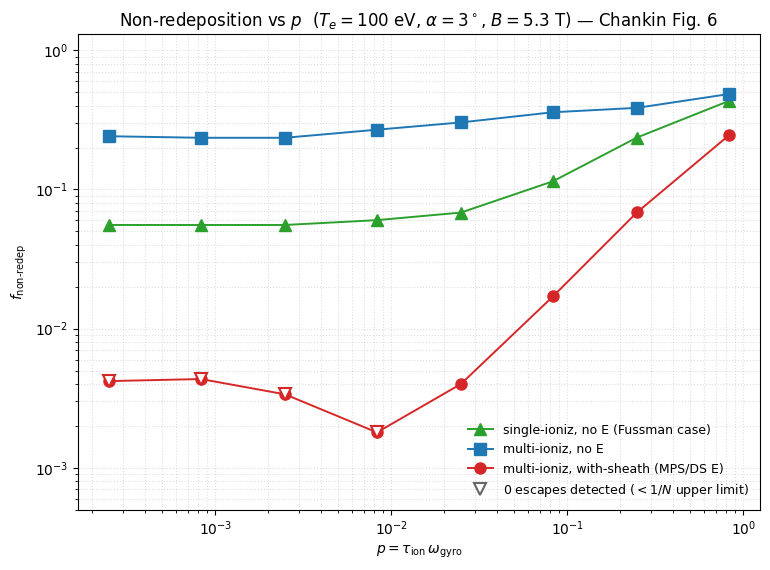

In [4]:
fig,ax=plt.subplots(figsize=(7.8,5.8))
# pp=np.logspace(-3,1.4,200); ax.plot(pp,pp**2/(1+pp**2),"k-",lw=2,
        # label=r"Fussman $p^2/(1+p^2)$ (geometry, no E)")
styles={"single":dict(color="C2",marker="^",label="single-ioniz, no E (Fussman case)"),
        "multi":dict(color="C0",marker="s",label="multi-ioniz, no E"),
        "full":dict(color="C3",marker="o",label="multi-ioniz, with-sheath (MPS/DS E)")}
for smode,st in styles.items():
    rows=sorted([r for (m,ne),r in T.items() if m==smode and np.isfinite(r.get("p",np.nan))],
                key=lambda r:r["p"])
    if not rows: continue
    N=[r["nredep"]+r["nesc"]+r["nair"] for r in rows]
    # zero-count points are censored on a log axis: draw them at the 1/N
    # upper limit with an open downward marker
    fplot=[r["f"] if r["f"]>0 else 1.0/n for r,n in zip(rows,N)]
    ax.plot([r["p"] for r in rows],fplot,"-",ms=8,lw=1.4,
            color=st["color"],marker=st["marker"],label=st["label"])
    cens=[(r["p"],1.0/n) for r,n in zip(rows,N) if r["f"]==0]
    if cens:
        ax.plot(*zip(*cens),ls="none",marker="v",ms=9,mfc="w",mec=st["color"],mew=1.5)
ax.plot([],[],ls="none",marker="v",ms=9,mfc="w",mec="0.4",mew=1.5,
        label=r"0 escapes detected ($<1/N$ upper limit)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$p=\tau_{\rm ion}\,\omega_{\rm gyro}$"); ax.set_ylabel(r"$f_{\rm non\text{-}redep}$")
ax.set_title(r"Non-redeposition vs $p$  ($T_e=100$ eV, $\alpha=3^\circ$, $B=5.3$ T) — Chankin Fig. 6")
ax.set_ylim(5e-4,1.3); ax.grid(True,which="both",ls=":",alpha=0.4); ax.legend(frameon=False,loc="lower right",fontsize=9)
plt.tight_layout(); plt.show()

## Single-atom orbits — Chankin Fig. 3

`./run_chankin.sh orbits` launches the 5 atoms in `particles.dat`
($\alpha=0$, $n_e=10^{21}$, no sheath, multi-ionization) and writes
`state/redepo.fan`. Each ion spirals up while climbing charge states
($\rho\propto1/Z$), the multi-loop spiral of Chankin's Fig. 3.

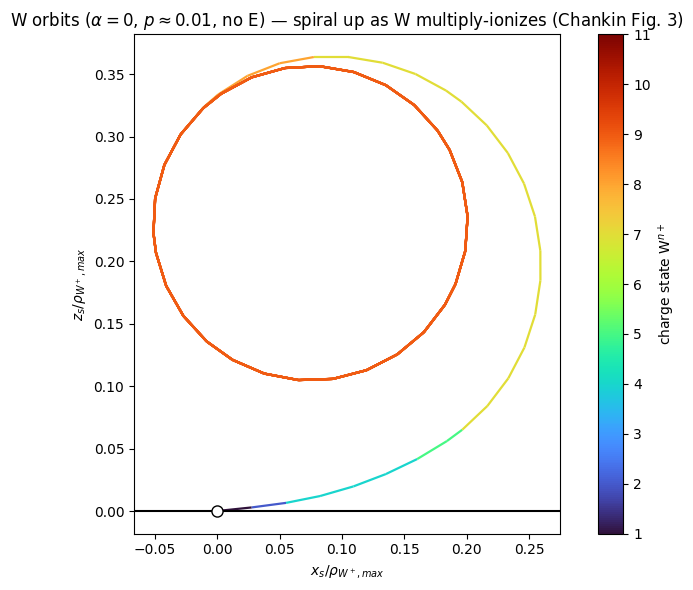

1 orbits; charge reached: id1->W8+


In [5]:
# --- gyro-plane orbits (x-z, perpendicular to B=+y), normalized to rho_W+,max ---
QE=1.602176634e-19; M_W=183.84*1.66053907e-27; B_FLD=5.3
FAN="state/redepo.fan"
if not os.path.exists(FAN):
    print("run the Fig-3 launch first (see command above) to create", FAN)
else:
    tr=collections.defaultdict(list); hdr=None; ia=False
    for line in open(FAN):
        if line.startswith("ITEM: ATOMS"): hdr=line.split()[2:]; ia=True; continue
        if line.startswith("ITEM:"): ia=False; continue
        if ia:
            p=line.split()
            if len(p)==len(hdr):
                d=dict(zip(hdr,p)); tr[int(d["id"])].append([float(d[k]) for k in ("type","x","z","vx","vz")])
    fig,ax=plt.subplots(figsize=(8,6)); cmap=plt.get_cmap("turbo"); norm=plt.Normalize(1,11)
    for pid,rows in sorted(tr.items()):
        a=np.array(rows); ty,x,z,vx,vz=a.T
        rho=M_W*np.hypot(vx[0],vz[0])/(QE*B_FLD)           # W+ Larmor radius at launch
        xs=(x-x[0])/rho; ys=(z-z[0])/rho
        seg=np.concatenate([np.c_[xs,ys].reshape(-1,1,2)[:-1],np.c_[xs,ys].reshape(-1,1,2)[1:]],axis=1)
        lc=LineCollection(seg,cmap=cmap,norm=norm,lw=1.6); lc.set_array(ty[:-1]); ax.add_collection(lc)
    ax.autoscale(); ax.axhline(0,color="k",lw=1.5); ax.plot(0,0,"o",mfc="w",mec="k",ms=8)
    ax.set_aspect("equal"); ax.set_xlabel(r"$x_s/\rho_{W^+,max}$"); ax.set_ylabel(r"$z_s/\rho_{W^+,max}$")
    ax.set_title(r"W orbits ($\alpha=0$, $p\approx0.01$, no E) — spiral up as W multiply-ionizes (Chankin Fig. 3)")
    sm=plt.cm.ScalarMappable(cmap=cmap,norm=norm); sm.set_array([])
    fig.colorbar(sm,ax=ax,label="charge state W$^{n+}$",ticks=range(1,12))
    plt.tight_layout(); plt.show()
    print(f"{len(tr)} orbits; charge reached: "+
          ", ".join(f"id{p}->W{int(np.array(r)[:,0].max())-1}+" for p,r in sorted(tr.items())))

## Chankin Fig. 6 and tables 3/4 — total non-redeposition and energy amplification

`./run_chankin.sh fig6`: monoenergetic W⁰ at $\xi_{W^0}=R_E\cdot\tfrac32 kT_i$
(Chankin's launch condition), $R_E\in\{0.1,0.3,1,3\}$, $T_e=T_i=100$ eV,
multi-ioniz + sheath E, $p$ scanned via $n_e$.

Two quantities per run, as in tables 3/4: $f_{\rm non\text{-}redep}$ and the
energy amplification factor $\langle E_{\rm impact}\rangle/\xi_{W^0}$. Impact
energy = kinetic energy at the last dump + $Z\,[\phi_{\rm tot}-\phi(z)]$, the
remaining sheath potential gain (CM profile ported from `sheath_models.cpp`).
Chankin's reference values use Stangeby's (table 3) and Brooks' (table 4) MPS
models; OpenEdge's Coulette–Manfredi sheath is a third model, so agreement is
expected in shape and magnitude, not digit-for-digit.

In [6]:
RE_INFO={"re01":(0.1,15.0),"re03":(0.3,45.0),"re1":(1.0,150.0),"re3":(3.0,450.0)}
M_CODE=3.077624296e-25     # W mass in plasma.species (all charge states)
EPS0=8.8541878128e-12; AMU_=1.66053906660e-27; ME=9.1093837015e-31

def phi_cm(te,ti,ne,B=5.3,alpha_n=87.0,mD=2.0):
    """CM sheath potential phi(d) [eV, positive drop], phi_total, d_max.
    Ported from sheath_models.cpp (post phi-blend fix, 2026-07-23)."""
    lamD=np.sqrt(EPS0*te/(ne*QE))
    vth=np.sqrt((te+ti)*QE/(2*mD*AMU_)); rho=vth/(QE*B/(mD*AMU_))
    a=90.0-alpha_n
    B1=np.exp(0.788600127141-0.0140352947024*a); B2=np.exp(-0.511290440114+0.0149209038566*a)
    K1=np.exp(-3.57918079952+0.0414523939029*a); K2=np.exp(-0.705851316996+0.000903186346144*a)
    K1s=K1*20.0/max(rho/lamD,1.0)
    ptot=0.5*np.log((mD*AMU_/(2*np.pi*ME))/(1+ti/te))*te
    sc=ptot/((B1+B2)*te); slow=sc*B1*te; fast=sc*B2*te
    lmps=rho*min(max(np.tan(np.radians(alpha_n)),1e-3),30.0)
    dmax=max(5*rho,10*lamD)
    def phi(d):
        s=d/lamD
        pc=slow*np.exp(-K1s*s); pf=fast*np.exp(-K2*s)
        if s<=60.0: return pc+pf
        pm=slow*np.exp(-K1s*60.0)*np.exp(-(s-60.0)*lamD/lmps)
        b=min((s-60.0)/60.0,1.0)
        return (1-b)*pc+b*pm+pf
    return phi,ptot,dmax

def fate_v(path, cut=0.5):
    """fate counts + (z,type,KE_eV) at last dump for redeposited particles"""
    born={}; lastk={}; lastz={}; lastt={}; lastv2={}
    cur=0; idx=None; ia=False; ts=False
    for line in open(path):
        if line.startswith("ITEM: TIMESTEP"): ia=False; ts=True; continue
        if ts: cur=int(line.split()[0]); ts=False; continue
        if line.startswith("ITEM: ATOMS"):
            if idx is None:
                h=line.split()[2:]
                idx=[h.index(k) for k in ("id","type","z","vx","vy","vz")]
            ia=True; continue
        if line.startswith("ITEM:"): ia=False; continue
        if ia:
            q=line.split()
            if len(q)<=max(idx): continue
            pid=int(q[idx[0]])
            if pid not in born: born[pid]=cur
            lastk[pid]=cur; lastt[pid]=int(q[idx[1]]); lastz[pid]=float(q[idx[2]])
            lastv2[pid]=sum(float(q[i])**2 for i in idx[3:])
    last=cur; dep=esc=air=0; hits=[]
    for pid,b in born.items():
        if b>cut*last: continue
        if lastk[pid]>=last: air+=1
        elif lastz[pid]>0.01: esc+=1
        else:
            dep+=1
            hits.append((lastz[pid],lastt[pid],0.5*M_CODE*lastv2[pid]/QE))
    non=esc+air
    return dict(nredep=dep,nesc=esc,nair=air,
                f=non/(non+dep) if (non+dep) else np.nan), hits

F6={}
for tag,path in runs.items():
    mm=re.match(r"(re01|re03|re1|re3)_ne([0-9.eE+-]+)$",tag)
    if not mm: continue
    case,ne=mm.group(1),float(mm.group(2))
    r,hits=fate_v(path)
    r["path"]=path
    RE,E0=RE_INFO[case]
    phi,ptot,dmax=phi_cm(TeV,TeV,ne)
    eimp=[ke+(t-1)*(ptot-phi(min(z,dmax))) for z,t,ke in hits if t>=2]
    r.update(case=case,ne=ne,RE=RE,E0=E0,
             amp=np.mean(eimp)/E0 if eimp else np.nan)
    F6[(case,ne)]=r

if F6:
    lo=min(F6.values(),key=lambda r:r["ne"])
    tau6=tau_measured(lo["path"]); SIGV6=1.0/(lo["ne"]*tau6)
    ne_lo=lo["ne"]
    for r in F6.values(): r["p"]=OMEGA_GYRO/(r["ne"]*SIGV6)
    print(f"calibration: ne={ne_lo:.0e} tau={tau6*1e6:.3f} us -> <sigma v>={SIGV6:.2e} m^3/s")
    for case in ("re01","re03","re1","re3"):
        rows=sorted([r for (c,_),r in F6.items() if c==case],key=lambda r:r["p"])
        if not rows: continue
        print(f"\n R_E={RE_INFO[case][0]:<4} (E0={RE_INFO[case][1]:.0f} eV): "
              f"{'p':>8} {'f_nonredep':>11} {'amp':>7} {'N':>5}")
        for r in rows:
            print(f"{'':24}{r['p']:8.4f} {r['f']:11.4f} {r['amp']:7.2f} "
                  f"{r['nredep']+r['nesc']+r['nair']:5d}")
else:
    print("no fig6 dumps yet -- run ./run_chankin.sh fig6")

calibration: ne=1e+18 tau=2.467 us -> <sigma v>=4.05e-13 m^3/s

 R_E=0.1  (E0=15 eV):        p  f_nonredep     amp     N
                          0.0069      0.0000   10.11   364
                          0.0229      0.0000   12.07   612
                          0.0686      0.0027   17.19   747
                          0.2287      0.0366   23.12   846
                          0.6861      0.1432   28.01   873
                          2.2871      0.3684   31.16   874
                          6.8614      0.5882   30.25   879

 R_E=0.3  (E0=45 eV):        p  f_nonredep     amp     N
                          0.0069      0.0000    5.18   576
                          0.0229      0.0057    7.30   703
                          0.0686      0.0492    9.85   813
                          0.2287      0.1266   12.08   845
                          0.6861      0.2353   12.40   867
                          2.2871      0.4053   11.87   876
                          6.8614      0.6325   11.40  

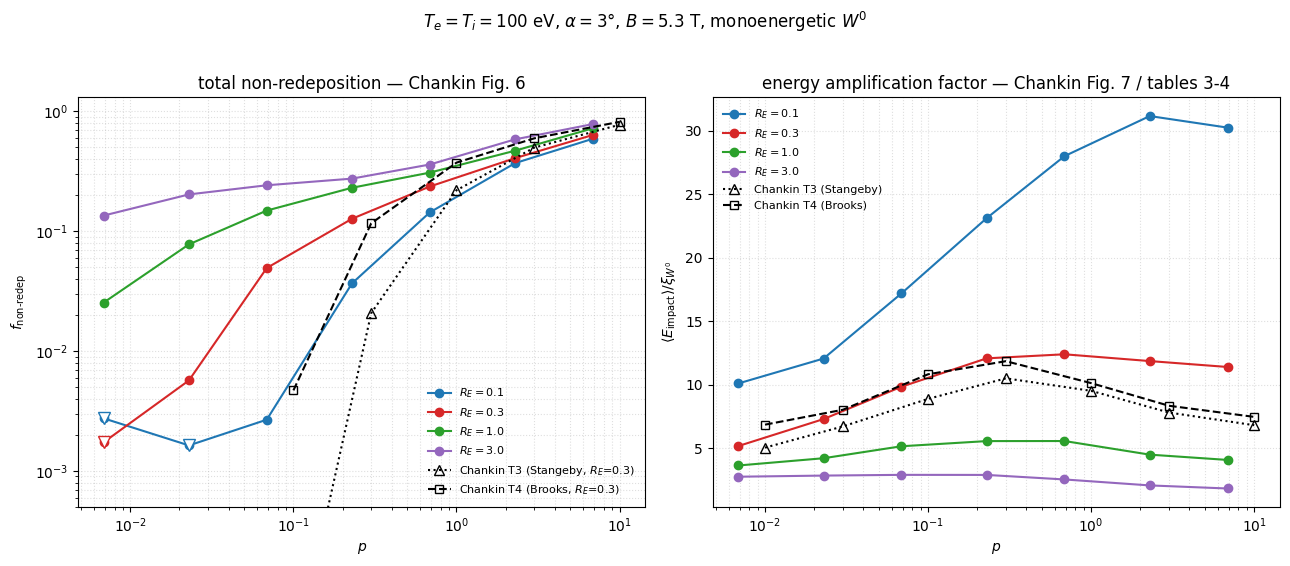

In [7]:
# Chankin table 3 (Stangeby MPS) and table 4 (Brooks MPS), Te=100 eV row, R_E=0.3
CH_P =[0.01,0.03,0.1,0.3,1.0,3.0,10.0]
CH3_F=[0,0,2.5e-5,0.0207,0.2188,0.4964,0.7694]
CH3_A=[5.0504,6.7200,8.8910,10.508,9.5236,7.8156,6.8160]
CH4_F=[0,0,0.0047,0.1161,0.3718,0.5933,0.8141]
CH4_A=[6.8596,8.0322,10.828,11.859,10.131,8.3482,7.4722]

if F6:
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5.5))
    cols={"re01":"C0","re03":"C3","re1":"C2","re3":"C4"}
    for case in ("re01","re03","re1","re3"):
        rows=sorted([r for (c,_),r in F6.items() if c==case],key=lambda r:r["p"])
        if not rows: continue
        N=[r["nredep"]+r["nesc"]+r["nair"] for r in rows]
        fpl=[r["f"] if r["f"]>0 else 1.0/n for r,n in zip(rows,N)]
        lab=f"$R_E={RE_INFO[case][0]}$"
        ax1.plot([r["p"] for r in rows],fpl,"-o",ms=6,color=cols[case],label=lab)
        cens=[(r["p"],1.0/n) for r,n in zip(rows,N) if r["f"]==0]
        if cens: ax1.plot(*zip(*cens),ls="none",marker="v",ms=8,mfc="w",mec=cols[case])
        ax2.plot([r["p"] for r in rows],[r["amp"] for r in rows],"-o",ms=6,
                 color=cols[case],label=lab)
    ax1.plot(CH_P,[f if f>0 else np.nan for f in CH3_F],"k^:",ms=7,mfc="none",
             label="Chankin T3 (Stangeby, $R_E$=0.3)")
    ax1.plot(CH_P,[f if f>0 else np.nan for f in CH4_F],"ks--",ms=6,mfc="none",
             label="Chankin T4 (Brooks, $R_E$=0.3)")
    ax1.set_xscale("log"); ax1.set_yscale("log"); ax1.set_ylim(5e-4,1.3)
    ax1.set_xlabel(r"$p$"); ax1.set_ylabel(r"$f_{\rm non\text{-}redep}$")
    ax1.set_title("total non-redeposition — Chankin Fig. 6")
    ax1.grid(True,which="both",ls=":",alpha=0.4); ax1.legend(frameon=False,fontsize=8)
    ax2.plot(CH_P,CH3_A,"k^:",ms=7,mfc="none",label="Chankin T3 (Stangeby)")
    ax2.plot(CH_P,CH4_A,"ks--",ms=6,mfc="none",label="Chankin T4 (Brooks)")
    ax2.set_xscale("log"); ax2.set_xlabel(r"$p$")
    ax2.set_ylabel(r"$\langle E_{\rm impact}\rangle/\xi_{W^0}$")
    ax2.set_title("energy amplification factor — Chankin Fig. 7 / tables 3-4")
    ax2.grid(True,which="both",ls=":",alpha=0.4); ax2.legend(frameon=False,fontsize=8)
    fig.suptitle(r"$T_e=T_i=100$ eV, $\alpha=3°$, $B=5.3$ T, monoenergetic $W^0$",y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("no fig6 dumps yet -- run ./run_chankin.sh fig6")

### Notes

- The no-sheath → with-sheath gap is the physics of interest: the MPS/DS
  field returns the stranded high-Z ions.
- `multi` above the Fussman law at small $p$ is expected — Fussman assumes a
  single ionization.
- Periodic laterals matter: absorbing x-walls clip ~1 mm orbits in the 4 mm
  box and floor $f_{\rm non\text{-}redep}$ near 0.4.
- Runs need `nemit 1`; scans made before 2026-07-23 also predate the sheath
  φ-blend fix in `sheath_models.cpp` and were discarded.
- ~$\pm0.01$–0.03 per point; more densities: extend `NE_LIST` in
  `run_chankin.sh`.
- Fig. 6/tables comparison (2026-07-24): energy amplification factors at
  $R_E=0.3$ land on Chankin's tables 3/4 values (peak ~12 at $p\sim0.3$–0.7,
  same shape), and the $R_E$ ordering matches his Fig. 7. $f_{\rm non-redep}$
  agrees for $p\gtrsim0.2$ and for large $R_E$; at small $p$ OpenEdge sits
  ~10× above Brooks — a region where Brooks and Stangeby themselves differ
  by >100× and where the sheath extent $d_{\max}$ decides the answer.
- **Sheath extent sensitivity** (`global pusher sheath dmax`, deck variable
  `sdmax`; 0 = auto $5\rho_i\approx1.6$ mm): auto reproduces Brooks-like
  values; $d_{\max}=4$ mm ($\approx$ Chankin's MPS width $10\rho_{i,D^+}$)
  reproduces **Stangeby's table 3** ($f=0.026$ vs 0.021 at $p=0.23$, <1e-3 vs
  2.5e-5 at $p=0.07$); 9 mm over-binds ($f=0$ everywhere). The knob spans the
  same model spread Chankin documents in his §6. Test dumps:
  `state/redepo.re03d4_*`, `re03d9_*`.